# 02b RC2 — ML Training

Applies the 04c classifier suite to the union SNP lists produced by 02b RC2.

Conditions tested for each top-N ∈ {100, 200, 500}:
- **chi2 only** — top-N by Chi² statistic
- **jsd only** — top-N by Jensen-Shannon Divergence
- **afdelta only** — top-N by Max AF Delta
- **union** — deduplicated union of all three

Output: accuracy comparison table + feature importance on the best set.

In [1]:
import sys
import os
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_root = Path.cwd()
while not (_root / 'scripts' / 'config.py').exists():
    if _root == _root.parent:
        raise RuntimeError("Cannot find project root")
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / 'scripts'))
print(f"Working directory: {os.getcwd()}")

import config as cfg
cfg.set_population_config("sea_jpt_cn")
PATHS = cfg.PATHS
ML = cfg.ML

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

print("All imports successful!")

Working directory: /home/ibmelab/Projects/AISNP-Research
All imports successful!


## Step 1: Load Genotype Matrix

In [2]:
numpy_cache = str(PATHS.OUTPUT_DIR / "genotype_matrix_rc2_cache.npz")
cols_cache  = str(PATHS.OUTPUT_DIR / "genotype_matrix_rc2_cols.txt")
SAMPLES_CSV = str(PATHS.EAS_SAMPLES_CSV)

if not (os.path.exists(numpy_cache) and os.path.exists(cols_cache)):
    raise FileNotFoundError(
        "Numpy cache not found. Run 02b_rc2_statistical_snp_selection.ipynb first."
    )

print("Loading numpy cache...")
t0 = time.time()
data = np.load(numpy_cache)
G_raw      = data['G']                          # (n_samples, n_snps), int8
sample_names = list(data['samples'].astype(str))
with open(cols_cache) as f:
    all_snp_ids = [l.strip() for l in f]
print(f"Loaded in {time.time()-t0:.1f}s  |  shape: {G_raw.shape}")

samples_df  = pd.read_csv(SAMPLES_CSV, header=None, names=['sample','pop','super_pop'])
pop_lookup  = dict(zip(samples_df['sample'], samples_df['pop']))
pop_labels  = np.array([pop_lookup.get(s, 'UNK') for s in sample_names])

le = LabelEncoder()
y  = pop_labels
y_enc = le.fit_transform(y)

# SNP id → column index map for fast lookup
snp_index = {snp: i for i, snp in enumerate(all_snp_ids)}

print(f"Populations: {dict(zip(*np.unique(pop_labels, return_counts=True)))}")
print(f"Classes: {le.classes_}")

Loading numpy cache...
Loaded in 0.7s  |  shape: (504, 614759)
Populations: {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}
Classes: ['CN' 'JPT' 'SEA']


## Step 2: Load RC2 Scores and Build Condition SNP Lists

In [3]:
scores_path = str(PATHS.OUTPUT_DIR / "02b_rc2_all_scores.csv")
if not os.path.exists(scores_path):
    raise FileNotFoundError(
        f"RC2 scores not found: {scores_path}\n"
        "Run 02b_rc2_statistical_snp_selection.ipynb first."
    )

scores_df = pd.read_csv(scores_path)
print(f"Loaded RC2 scores: {scores_df.shape}")

top_ns = [100, 200, 500]

conditions = {}
for N in top_ns:
    top_chi2    = list(scores_df.nlargest(N, 'chi2_stat')['snp_id'])
    top_jsd     = list(scores_df.nlargest(N, 'jsd')['snp_id'])
    top_afdelta = list(scores_df.nlargest(N, 'af_max_delta')['snp_id'])

    union_ids_path = str(PATHS.OUTPUT_DIR / f"02b_rc2_union_top{N}_ids.txt")
    if os.path.exists(union_ids_path):
        # pd.read_csv correctly strips CSV quoting.
        # Old files written by pandas to_csv wrap SNP IDs (which contain commas)
        # in double quotes — open().strip() keeps those quotes, pd.read_csv removes them.
        union_snps = pd.read_csv(union_ids_path, header=None, dtype=str)[0].tolist()
    else:
        seen = {}
        for s in top_chi2 + top_jsd + top_afdelta:
            seen[s] = None
        union_snps = list(seen.keys())

    conditions[(N, 'chi2')]    = top_chi2
    conditions[(N, 'jsd')]     = top_jsd
    conditions[(N, 'afdelta')] = top_afdelta
    conditions[(N, 'union')]   = union_snps

print(f"\nConditions ({len(conditions)} total):")
for (N, method), snps in conditions.items():
    available = sum(1 for s in snps if s in snp_index)
    print(f"  top-{N:3d}  {method:8s}: {len(snps):4d} SNPs  ({available} in matrix)")

Loaded RC2 scores: (614759, 8)

Conditions (12 total):
  top-100  chi2    :  100 SNPs  (100 in matrix)
  top-100  jsd     :  100 SNPs  (100 in matrix)
  top-100  afdelta :  100 SNPs  (100 in matrix)
  top-100  union   :  210 SNPs  (210 in matrix)
  top-200  chi2    :  200 SNPs  (200 in matrix)
  top-200  jsd     :  200 SNPs  (200 in matrix)
  top-200  afdelta :  200 SNPs  (200 in matrix)
  top-200  union   :  404 SNPs  (404 in matrix)
  top-500  chi2    :  500 SNPs  (500 in matrix)
  top-500  jsd     :  500 SNPs  (500 in matrix)
  top-500  afdelta :  500 SNPs  (500 in matrix)
  top-500  union   : 1005 SNPs  (1005 in matrix)


## Step 3: Define Classifiers

In [4]:
classifiers = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    'Logistic Reg':       LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', n_jobs=-1),
    'SVM (RBF)':          SVC(kernel='rbf', random_state=42),
    'SVM (Linear)':       SVC(kernel='linear', random_state=42),
    'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':        GaussianNB(),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost':           AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'MLP':                MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True),
}

# Which classifiers need scaled input
NEEDS_SCALE = {'Logistic Reg', 'SVM (RBF)', 'SVM (Linear)', 'MLP'}
# Which classifiers need integer-encoded y
NEEDS_ENC   = {'XGBoost', 'MLP'}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Classifiers: {len(classifiers)}")
print(f"CV: 5-fold stratified")

Classifiers: 10
CV: 5-fold stratified


## Step 4: Run CV Across All Conditions

4 methods × 3 top-N values = 12 conditions × 10 classifiers.

In [5]:
all_results = []
scoring = {'accuracy': 'accuracy', 'f1': 'f1_weighted'}

total = len(conditions) * len(classifiers)
done  = 0

for (N, method), snp_list in conditions.items():
    # Build feature matrix for this condition
    avail_idx = [snp_index[s] for s in snp_list if s in snp_index]
    avail_snps = [snp_list[snp_list.index(all_snp_ids[i])] for i in avail_idx]
    X_cond = G_raw[:, avail_idx].astype(np.float32)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cond)
    n_feat = X_cond.shape[1]

    print(f"\n── top-{N} {method:8s} ({n_feat} SNPs) ──")

    for clf_name, clf in classifiers.items():
        X_use = X_scaled if clf_name in NEEDS_SCALE else X_cond
        y_use = y_enc    if clf_name in NEEDS_ENC   else y

        try:
            scores = cross_validate(clf, X_use, y_use, cv=cv, scoring=scoring,
                                    return_train_score=True, n_jobs=1)
            row = {
                'top_n':       N,
                'method':      method,
                'n_snps':      n_feat,
                'classifier':  clf_name,
                'acc_mean':    scores['test_accuracy'].mean(),
                'acc_std':     scores['test_accuracy'].std(),
                'f1_mean':     scores['test_f1'].mean(),
                'train_acc':   scores['train_accuracy'].mean(),
                'overfit_gap': scores['train_accuracy'].mean() - scores['test_accuracy'].mean(),
            }
        except Exception as e:
            row = {'top_n': N, 'method': method, 'n_snps': n_feat,
                   'classifier': clf_name, 'acc_mean': np.nan, 'acc_std': np.nan,
                   'f1_mean': np.nan, 'train_acc': np.nan, 'overfit_gap': np.nan}

        all_results.append(row)
        done += 1
        print(f"  {clf_name:22s}  acc={row['acc_mean']:.4f} ± {row['acc_std']:.4f}  [{done}/{total}]")

results_df = pd.DataFrame(all_results)
print(f"\nDone. {len(results_df)} results.")


── top-100 chi2     (100 SNPs) ──
  Random Forest           acc=0.9206 ± 0.0300  [1/120]
  XGBoost                 acc=0.9027 ± 0.0331  [2/120]
  Logistic Reg            acc=0.9405 ± 0.0293  [3/120]
  SVM (RBF)               acc=0.9624 ± 0.0229  [4/120]
  SVM (Linear)            acc=0.9206 ± 0.0397  [5/120]
  KNN                     acc=0.7936 ± 0.0323  [6/120]
  Naive Bayes             acc=0.7244 ± 0.0567  [7/120]
  Gradient Boosting       acc=0.8949 ± 0.0159  [8/120]
  AdaBoost                acc=0.8710 ± 0.0370  [9/120]
  MLP                     acc=0.9405 ± 0.0266  [10/120]

── top-100 jsd      (100 SNPs) ──
  Random Forest           acc=0.9167 ± 0.0204  [11/120]
  XGBoost                 acc=0.9206 ± 0.0188  [12/120]
  Logistic Reg            acc=0.9524 ± 0.0269  [13/120]
  SVM (RBF)               acc=0.9524 ± 0.0296  [14/120]
  SVM (Linear)            acc=0.9345 ± 0.0222  [15/120]
  KNN                     acc=0.8889 ± 0.0421  [16/120]
  Naive Bayes             acc=0.7560 ± 0.03

## Step 5: Results Summary

In [6]:
# Best classifier per condition
best_per_condition = (
    results_df.sort_values('acc_mean', ascending=False)
    .groupby(['top_n', 'method'])
    .first()
    .reset_index()
    [['top_n', 'method', 'n_snps', 'classifier', 'acc_mean', 'acc_std', 'f1_mean', 'overfit_gap']]
)

print("Best classifier per condition:")
print("=" * 85)
display(best_per_condition.to_string(index=False))

Best classifier per condition:


' top_n  method  n_snps   classifier  acc_mean  acc_std  f1_mean  overfit_gap\n   100 afdelta     100    SVM (RBF)  0.944455 0.011833 0.944532     0.054057\n   100    chi2     100    SVM (RBF)  0.962356 0.022899 0.962339     0.019785\n   100     jsd     100          MLP  0.952436 0.052892 0.951922     0.027719\n   100   union     210    SVM (RBF)  0.978198 0.017021 0.978153     0.018329\n   200 afdelta     200 Logistic Reg  0.974238 0.011855 0.974245     0.025762\n   200    chi2     200 Logistic Reg  0.964277 0.023940 0.964189     0.035723\n   200     jsd     200    SVM (RBF)  0.978218 0.021143 0.978155     0.021286\n   200   union     404 SVM (Linear)  0.982158 0.013123 0.982160     0.017842\n   500 afdelta     500    SVM (RBF)  0.986119 0.010089 0.986122     0.013881\n   500    chi2     500    SVM (RBF)  0.972257 0.022035 0.972189     0.022286\n   500     jsd     500 Logistic Reg  0.984119 0.013442 0.984112     0.015881\n   500   union    1005    SVM (RBF)  0.990079 0.006262 0.990088

In [7]:
# Pivot: best accuracy per (N, method) — max over classifiers
pivot_acc = results_df.groupby(['top_n', 'method'])['acc_mean'].max().unstack('method')
# Reorder columns
col_order = [c for c in ['chi2', 'jsd', 'afdelta', 'union'] if c in pivot_acc.columns]
pivot_acc = pivot_acc[col_order]

print("\nBest accuracy per condition (max over classifiers):")
display(pivot_acc.round(4))

# Pivot: mean accuracy (averaged over classifiers) — shows ensemble signal
pivot_mean = results_df.groupby(['top_n', 'method'])['acc_mean'].mean().unstack('method')[col_order]
print("\nMean accuracy per condition (mean over classifiers):")
display(pivot_mean.round(4))


Best accuracy per condition (max over classifiers):


method,chi2,jsd,afdelta,union
top_n,,,,
100,0.9624,0.9524,0.9445,0.9782
200,0.9643,0.9782,0.9742,0.9822
500,0.9723,0.9841,0.9861,0.9901



Mean accuracy per condition (mean over classifiers):


method,chi2,jsd,afdelta,union
top_n,,,,
100,0.8871,0.9046,0.8785,0.9202
200,0.8976,0.9270,0.9143,0.9304
500,0.8984,0.9325,0.9303,0.9345


## Step 6: Visualisations

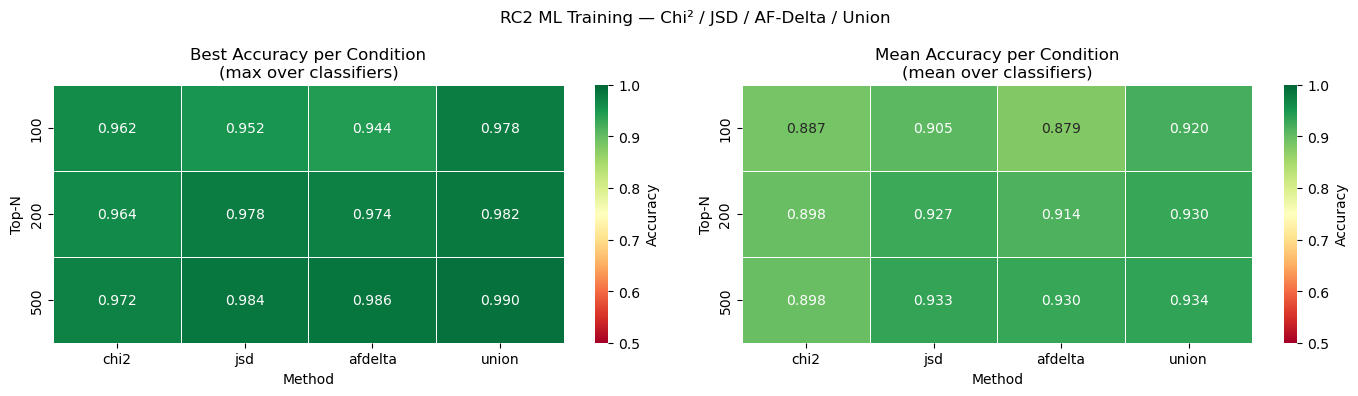

In [8]:
# ── Heatmap: best accuracy per (N, method) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Best Accuracy per Condition\n(max over classifiers)')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Top-N')

sns.heatmap(pivot_mean, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Accuracy'})
axes[1].set_title('Mean Accuracy per Condition\n(mean over classifiers)')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Top-N')

plt.suptitle('RC2 ML Training — Chi² / JSD / AF-Delta / Union', fontsize=12)
plt.tight_layout()
output_prefix = str(PATHS.OUTPUT_DIR / "02b_rc2_ml")
plt.savefig(f"{output_prefix}_accuracy_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

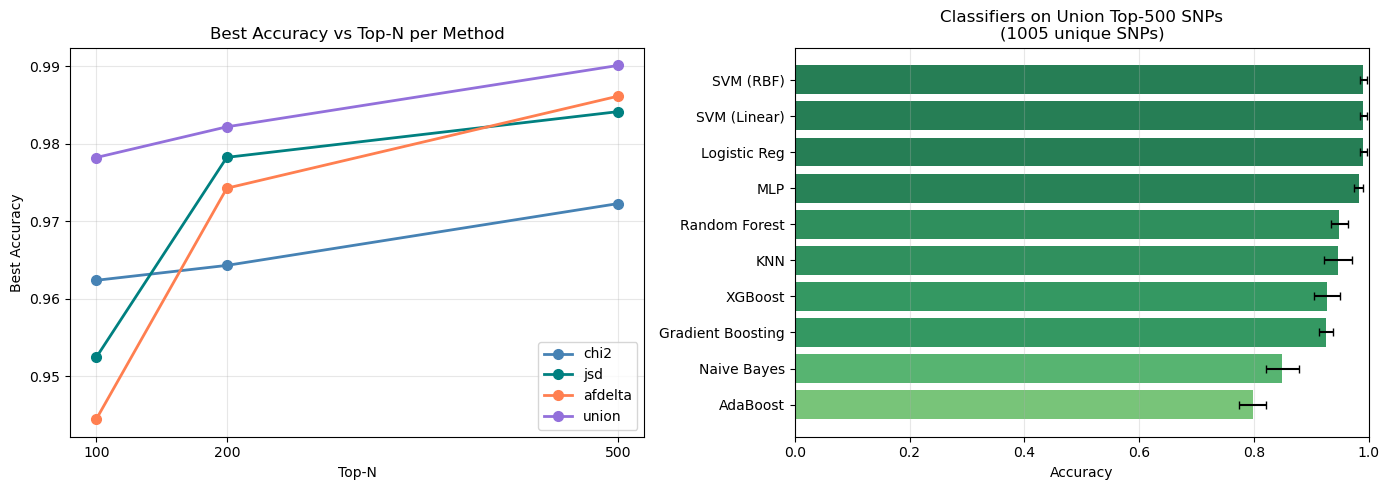

In [9]:
# ── Line plot: accuracy vs top-N per method ───────────────────────────────────
method_colors = {'chi2': 'steelblue', 'jsd': 'teal', 'afdelta': 'coral', 'union': 'mediumpurple'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method in col_order:
    sub = results_df[results_df['method'] == method]
    best_by_n = sub.groupby('top_n')['acc_mean'].max()
    axes[0].plot(best_by_n.index, best_by_n.values, 'o-',
                 color=method_colors[method], label=method, linewidth=2, markersize=7)

axes[0].set_xlabel('Top-N')
axes[0].set_ylabel('Best Accuracy')
axes[0].set_title('Best Accuracy vs Top-N per Method')
axes[0].legend()
axes[0].set_xticks(top_ns)
axes[0].grid(alpha=0.3)

# Per-classifier accuracy at best N (union, highest N)
best_n = max(top_ns)
sub_union = results_df[(results_df['top_n'] == best_n) & (results_df['method'] == 'union')]
sub_union = sub_union.sort_values('acc_mean', ascending=True)
colors_bar = plt.cm.RdYlGn(sub_union['acc_mean'].values / sub_union['acc_mean'].max())
axes[1].barh(sub_union['classifier'], sub_union['acc_mean'],
             xerr=sub_union['acc_std'], color=colors_bar, capsize=3, alpha=0.85)
axes[1].set_xlabel('Accuracy')
axes[1].set_title(f'Classifiers on Union Top-{best_n} SNPs\n({sub_union["n_snps"].iloc[0]} unique SNPs)')
axes[1].set_xlim(0, 1)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f"{output_prefix}_accuracy_lines.png", dpi=150, bbox_inches='tight')
plt.show()

Best condition: top-500 union  (1005 SNPs, Logistic Reg, acc=0.9901)
PCA variance (PC1+PC2+PC3): 16.1%


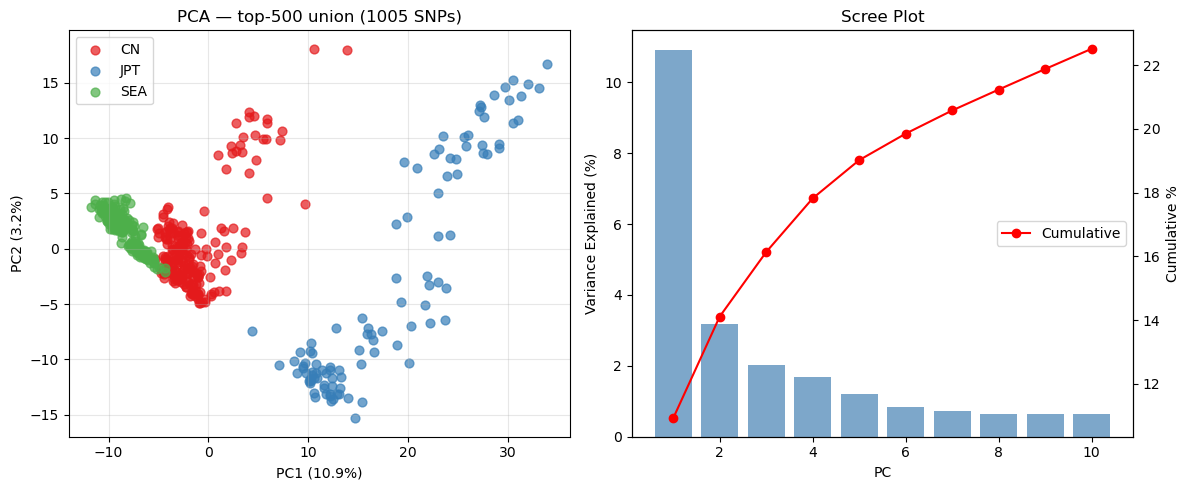

In [10]:
# ── PCA of best condition ─────────────────────────────────────────────────────
# Find best condition overall
best_row = results_df.loc[results_df['acc_mean'].idxmax()]
best_N, best_method = int(best_row['top_n']), best_row['method']
best_snp_list = conditions[(best_N, best_method)]
best_idx  = [snp_index[s] for s in best_snp_list if s in snp_index]
X_best    = G_raw[:, best_idx].astype(np.float32)
X_best_sc = StandardScaler().fit_transform(X_best)

n_pca = min(10, X_best.shape[1])
pca = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_best_sc)

print(f"Best condition: top-{best_N} {best_method}  "
      f"({X_best.shape[1]} SNPs, {best_row['classifier']}, acc={best_row['acc_mean']:.4f})")
print(f"PCA variance (PC1+PC2+PC3): {sum(pca.explained_variance_ratio_[:3])*100:.1f}%")

pop_colors = {'CN': '#e41a1c', 'JPT': '#377eb8', 'SEA': '#4daf4a'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for pop in le.classes_:
    mask = y == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=pop_colors.get(pop, 'gray'), label=pop, alpha=0.7, s=40)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA — top-{best_N} {best_method} ({X_best.shape[1]} SNPs)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scree
axes[1].bar(range(1, n_pca+1), pca.explained_variance_ratio_*100, color='steelblue', alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(range(1, n_pca+1), np.cumsum(pca.explained_variance_ratio_)*100, 'r-o', label='Cumulative')
ax2.set_ylabel('Cumulative %')
ax2.legend(loc='right')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot')

plt.tight_layout()
plt.savefig(f"{output_prefix}_pca_best.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Feature Importance on Best Condition

In [11]:
best_snps_available = [best_snp_list[best_snp_list.index(all_snp_ids[i])] for i in best_idx]

# RF importance
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_best, y)

# LR importance
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', n_jobs=-1)
lr.fit(X_best_sc, y)

imp_df = pd.DataFrame({
    'snp_id':       best_snps_available,
    'rf_importance': rf.feature_importances_,
    'lr_importance': np.abs(lr.coef_).mean(axis=0),
})
imp_df['rank_rf'] = imp_df['rf_importance'].rank(ascending=False)
imp_df['rank_lr'] = imp_df['lr_importance'].rank(ascending=False)
imp_df['avg_rank'] = (imp_df['rank_rf'] + imp_df['rank_lr']) / 2
imp_df = imp_df.sort_values('avg_rank')

# Annotate which method each SNP came from
top_chi2_set    = set(conditions[(best_N, 'chi2')])
top_jsd_set     = set(conditions[(best_N, 'jsd')])
top_afdelta_set = set(conditions[(best_N, 'afdelta')])

def source_label(snp):
    parts = []
    if snp in top_chi2_set:    parts.append('chi2')
    if snp in top_jsd_set:     parts.append('jsd')
    if snp in top_afdelta_set: parts.append('afd')
    return '+'.join(parts)

imp_df['source'] = imp_df['snp_id'].apply(source_label)

print(f"Top-30 SNPs by combined RF+LR rank ({best_method} top-{best_N}):")
display(imp_df[['snp_id', 'rf_importance', 'lr_importance', 'avg_rank', 'source']].head(30))

Top-30 SNPs by combined RF+LR rank (union top-500):


,snp_id,rf_importance,lr_importance,avg_rank,source
2,"19:54792079[b37]G,T",0.015979,0.082000,2.5,chi2+jsd+afd
58,"9:37486004[b37]C,G",0.011166,0.066812,7.5,chi2+jsd
0,"4:17813761[b37]G,A",0.021937,0.055385,13.0,chi2+jsd+afd
6,"21:38533017[b37]G,A",0.015223,0.056957,14.5,chi2+jsd
104,"16:33974960[b37]G,A",0.007591,0.061891,15.5,chi2+jsd+afd
62,"6:152588967[b37]C,G",0.006841,0.061296,17.5,chi2+jsd
12,"3:152553769[b37]C,T",0.014713,0.053301,19.0,chi2+jsd
1,"1:12387655[b37]G,A",0.017619,0.049313,22.0,chi2+jsd
70,"6:32726930[b37]G,A",0.003157,0.070553,24.0,chi2+jsd
57,"8:145095693[b37]A,C",0.008444,0.050532,24.5,chi2+jsd


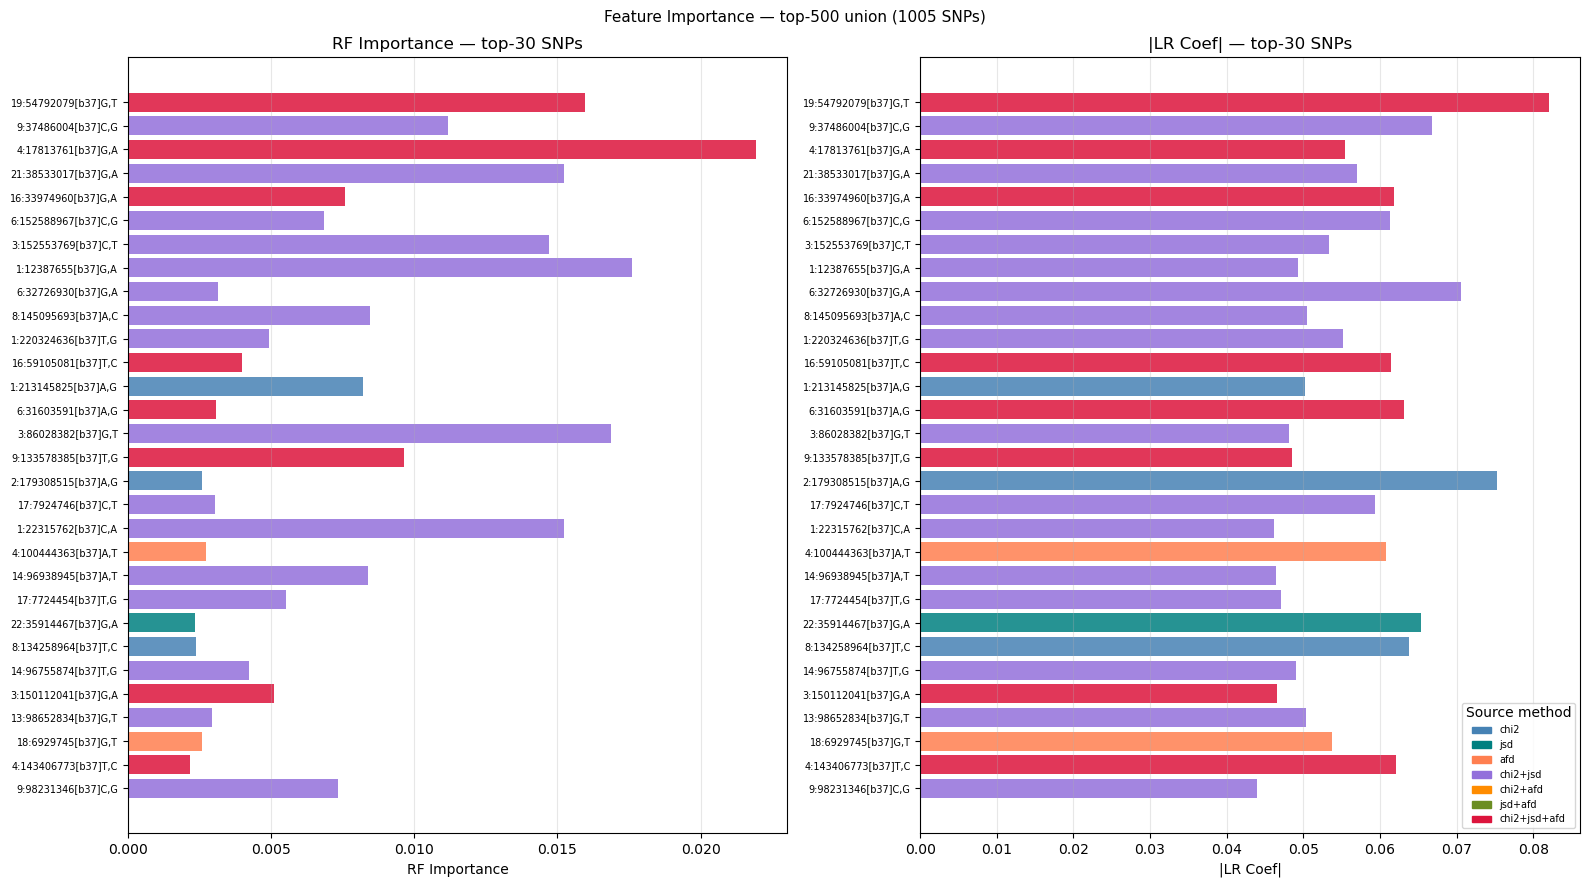

In [12]:
n_show = min(30, len(imp_df))
top_imp = imp_df.head(n_show)

source_colors = {
    'chi2':          'steelblue',
    'jsd':           'teal',
    'afd':           'coral',
    'chi2+jsd':      'mediumpurple',
    'chi2+afd':      'darkorange',
    'jsd+afd':       'olivedrab',
    'chi2+jsd+afd':  'crimson',
}

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, n_show * 0.3)))

for ax, (col, label) in zip(axes, [('rf_importance', 'RF Importance'), ('lr_importance', '|LR Coef|')]):
    bar_colors = [source_colors.get(s, 'gray') for s in top_imp['source']]
    ax.barh(range(n_show), top_imp[col].values, color=bar_colors, alpha=0.85)
    ax.set_yticks(range(n_show))
    ax.set_yticklabels(top_imp['snp_id'].values, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel(label)
    ax.set_title(f'{label} — top-{n_show} SNPs')
    ax.grid(alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=k) for k, c in source_colors.items()]
axes[1].legend(handles=legend_handles, title='Source method', fontsize=7,
               loc='lower right', framealpha=0.8)

plt.suptitle(f'Feature Importance — top-{best_N} {best_method} ({X_best.shape[1]} SNPs)', fontsize=11)
plt.tight_layout()
plt.savefig(f"{output_prefix}_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Save Results

In [13]:
results_df.to_csv(f"{output_prefix}_all_cv_results.csv", index=False)
print(f"Saved: {output_prefix}_all_cv_results.csv")

best_per_condition.to_csv(f"{output_prefix}_best_per_condition.csv", index=False)
print(f"Saved: {output_prefix}_best_per_condition.csv")

imp_df.to_csv(f"{output_prefix}_feature_importance.csv", index=False)
print(f"Saved: {output_prefix}_feature_importance.csv")

# Save top SNPs from best condition (ranked by avg_rank) for downstream use
top_snps_path = f"{output_prefix}_top_snps_best_condition.txt"
imp_df['snp_id'].to_csv(top_snps_path, index=False, header=False)
print(f"Saved: {top_snps_path}")

Saved: data/1000genomes/output_sea_jpt_cn/02b_rc2_ml_all_cv_results.csv
Saved: data/1000genomes/output_sea_jpt_cn/02b_rc2_ml_best_per_condition.csv
Saved: data/1000genomes/output_sea_jpt_cn/02b_rc2_ml_feature_importance.csv
Saved: data/1000genomes/output_sea_jpt_cn/02b_rc2_ml_top_snps_best_condition.txt


## Summary

In [14]:
print("=" * 70)
print("02b RC2 ML TRAINING SUMMARY")
print("=" * 70)
print(f"\nDataset: {G_raw.shape[0]} samples  |  populations: {list(le.classes_)}")
print(f"Conditions: {len(conditions)} ({len(top_ns)} top-N × 4 methods)")
print(f"Classifiers: {len(classifiers)}")
print(f"CV: 5-fold stratified\n")

print("Best accuracy per condition (max over classifiers):")
print(pivot_acc.round(4).to_string())

print(f"\n{'─'*70}")
print(f"Overall best:")
print(f"  top-{best_N}  {best_method}  {best_row['classifier']}")
print(f"  acc = {best_row['acc_mean']:.4f} ± {best_row['acc_std']:.4f}")
print(f"  f1  = {best_row['f1_mean']:.4f}")

print(f"\nTop-10 SNPs from best condition (RF+LR rank):")
for _, row in imp_df.head(10).iterrows():
    print(f"  {row['snp_id']:35s}  [{row['source']}]")

print(f"\nOutput files:")
print(f"  {output_prefix}_all_cv_results.csv")
print(f"  {output_prefix}_best_per_condition.csv")
print(f"  {output_prefix}_feature_importance.csv")
print(f"  {output_prefix}_top_snps_best_condition.txt")
print(f"\nNext: 05_model_evaluation.ipynb for final comparison.")

02b RC2 ML TRAINING SUMMARY

Dataset: 504 samples  |  populations: [np.str_('CN'), np.str_('JPT'), np.str_('SEA')]
Conditions: 12 (3 top-N × 4 methods)
Classifiers: 10
CV: 5-fold stratified

Best accuracy per condition (max over classifiers):
method    chi2     jsd  afdelta   union
top_n                                  
100     0.9624  0.9524   0.9445  0.9782
200     0.9643  0.9782   0.9742  0.9822
500     0.9723  0.9841   0.9861  0.9901

──────────────────────────────────────────────────────────────────────
Overall best:
  top-500  union  Logistic Reg
  acc = 0.9901 ± 0.0063
  f1  = 0.9901

Top-10 SNPs from best condition (RF+LR rank):
  19:54792079[b37]G,T                  [chi2+jsd+afd]
  9:37486004[b37]C,G                   [chi2+jsd]
  4:17813761[b37]G,A                   [chi2+jsd+afd]
  21:38533017[b37]G,A                  [chi2+jsd]
  16:33974960[b37]G,A                  [chi2+jsd+afd]
  6:152588967[b37]C,G                  [chi2+jsd]
  3:152553769[b37]C,T                  [ch